In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('seaborn-v0_8-dark')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (14, 10),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

from TB.utils import make_secondary_axis_plot_v2

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

In [2]:
import rateslib as rl
import QuantLib as ql

from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB

from MDP.IRSwaps.SDR_INTRADAY.rl_curve_utils.stir_curve_building_utils import fetch_stir_market_data

from Query.IRSwaps.IRSwapQuery import IRSwapQuery, IRSwapStructure
from Query.IRSwaps.IRSwapStructure import IRSwapStructureFunctionMap
from Query.IRSwaps.IRSwapValue import IRSwapValue, IRSwapValueFunctionMap

# fmt: off
import Query.IRSwaps.adapter  # noqa: F401
# fmt: on

from utils.ql_utils import datetime_to_ql_date, ql_date_to_datetime 

In [3]:
curve_mdp = IRSwapsMDP(source="CME_NY_EOD_LIVE-rl_basic")
tb = IRSwapsTB(mdp=curve_mdp)

In [4]:
curve = "USD-SOFR-1D"
timestamp = "live"
# timestamp = NY_tz.localize(datetime.datetime(2025, 10, 9, 17, 00))
# timestamp = datetime.date(2025, 10, 9)

curve_handle = curve_mdp._get_curve(curve_name=curve, timestamp=timestamp)
_, sfrs, _ = fetch_stir_market_data(
    curve, snap_local=timestamp, fixings=None, side="mid", include_serff=False, n_ser_contracts=0, n_sfr_contracts=24, use_globex=False
)

# # risk model
# imms = ["Z25", "H26", "M26", "U26", "Z26", "H27", "M27", "U27", "Z27", "H28", "M28", "U28", "Z28"]
# sfrs = {}
# for imm in imms:
#     sfrs[imm] = rl.STIRFuture(
#         effective=rl.scheduling.get_imm(code=imm), termination=rl.scheduling.next_imm(rl.scheduling.get_imm(code=imm)), spec="usd_stir", curves=curve_handle.handle()
#     )

# mt_tenors = ["5Y", "7Y", "10Y", "20Y", "30Y"]
# # mt_tenors = ["5Y", "10Y", "30Y"]
# mt_irs = {}
# for t in mt_tenors:
#     q = IRSwapQuery(curve="USD-SOFR-1D", tenor=t, structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1})
#     pkg, _ = q.resolve_package(pricer_or_curve=curve_handle)
#     mt_irs[t] = pkg[0]

# rl_curve_risk_instruments = sfrs | mt_irs
# rl_curve_risk_solver = rl.Solver(
#     curves=[curve_handle.handle()],
#     instruments=rl_curve_risk_instruments.values(),
#     instrument_labels=rl_curve_risk_instruments.keys(),
#     s=[r.rate().real for r in rl_curve_risk_instruments.values()],
#     id=curve_handle.id(),
#     func_tol=1e-8,
#     conv_tol=1e-10,
# )

# x_data_num, y_data_rate = curve_handle.handle()._plot_rates("1d", left=rl.NoInput(0), right=rl.NoInput(0))
# plot_data_dict = dict(zip(x_data_num, [y.real for y in y_data_rate]))

# calendar = ql.UnitedStates(ql.UnitedStates.FederalReserve)
# filtered_plot_data = {dt: rate for dt, rate in plot_data_dict.items() if calendar.isBusinessDay(ql.Date(dt.day, dt.month, dt.year))}

# x_business_days = list(filtered_plot_data.keys())
# y_business_rates = list(filtered_plot_data.values())
# curve_nodes = curve_handle.handle().nodes._nodes.keys()

# fig = go.Figure()
# fig.add_trace(go.Scatter(x=x_business_days, y=y_business_rates, mode="lines", name="1D"))

# tick_vals = [pd.Timestamp(t).tz_localize(None) for t in curve_nodes]
# tick_text = [pd.Timestamp(t).strftime("%Y-%m-%d") for t in tick_vals]

# fig.update_layout(
#     title=f"{curve_handle.meta()["id"]} | {curve_handle.meta()["timestamp"]} | 1d curve",
#     template="plotly_dark",
#     margin=dict(l=40, r=20, t=60, b=80),
#     xaxis=dict(tickmode="array", tickvals=tick_vals, ticktext=tick_text, tickangle=45, showgrid=True),
#     height=550,
#     width=1200,
#     yaxis=dict(showgrid=True),
# )
# fig.update_xaxes(
#     showspikes=True,
#     spikecolor="white",
#     spikesnap="cursor",
#     spikemode="across",
#     showgrid=True,
# )
# fig.update_yaxes(
#     showspikes=True,
#     spikecolor="white",
#     spikesnap="cursor",
#     spikethickness=0.5,
#     showgrid=True,
# )

# fig.show()

FETCHING ERIS INTRADAY DISC CURVE...: 100%|██████████| 1/1 [00:00<00:00,  2.56it/s]


In [ ]:
imm_start = "Z25"
imm_end = rl.next_imm(rl.get_imm(code=imm_start)).date()
# imm_end = rl.next_imm(rl.next_imm(rl.next_imm(rl.next_imm(rl.get_imm(code=imm_start)))))


risk = 25
outright_query = IRSwapQuery(
    curve=curve,
    effective_date=rl.get_imm(code=imm_start).date(),
    maturity_date=imm_end,
    structure=IRSwapStructure.OUTRIGHT,
    value=IRSwapValue.CVX_ADJ,
    structure_kwargs={"bpv": 1},
)
outright_pkg, outright_rws = outright_query.resolve_package(pricer_or_curve=curve_handle)

outright_vmap = outright_query.build_value_map(pricer_or_curve=curve_handle, package=outright_pkg, risk_weights=outright_rws)
print(f"{imm_start} CVX ADJ", outright_vmap.apply(value=IRSwapValue.CVX_ADJ, **{"sfr": [sfrs[f"SFR{imm_start}"]]}))

In [38]:
outright_query.col_name()

'USD-SOFR-1D 2026-12-16/2027-03-17 OUTRIGHT CVX_ADJ'

In [53]:
# from MDP.IRSwaps.SDR_INTRADAY.rl_curve_utils.stir_curve_building_utils import get_barchart_timeseries
# df = get_barchart_timeseries(
#     tickers=["`SFRZ25-SFRZ26`"],
#     start=datetime.date(2025, 1, 1),
#     end=datetime.date(2025, 10, 10),
#     interval=None,
#     use_globex=False,
# )
# df

In [4]:
sfr_cvx_df = tb.sfr_cvx_adj(
    items=["sfr8", "sfr12"],
    start=datetime.date(2025, 1, 1),
    end=datetime.date(2025, 10, 10),
    # ignore_cache=True
)
sfr_cvx_df

# sfr_cvx_df = tb.sfr_cvx_adj_v2(
#     items=["Z25"],
#     start=datetime.date(2025, 1, 1),
#     end=datetime.date(2025, 10, 9),
#     # ignore_cache=True
# )
# sfr_cvx_df

SFR CVX...: 100%|██████████| 1/1 [00:12<00:00, 12.21s/it]


,USD-SOFR-1D SFR12 OUTRIGHT CVX_ADJ,USD-SOFR-1D SFR8 OUTRIGHT CVX_ADJ
Date,,
2025-01-02,4.887,1.643
2025-01-03,4.879,1.639
2025-01-06,4.856,1.571
2025-01-07,4.848,1.567
2025-01-08,4.840,1.563
...,...,...
2025-10-06,3.939,1.226
2025-10-07,3.933,1.223
2025-10-08,3.926,1.220


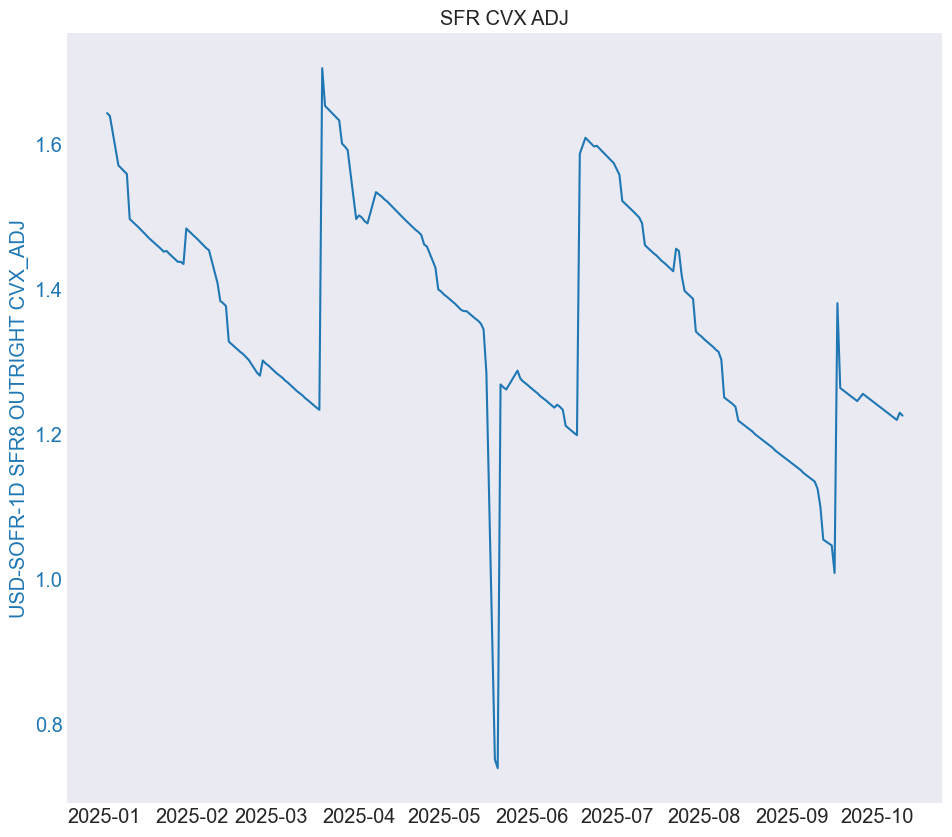

In [6]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot_v2(
    title="SFR CVX ADJ"
)

# sfr_cvx_df["z8z9 cvx"] = sfr_cvx_df["USD-SOFR-1D Z28 OUTRIGHT CVX_ADJ"] - sfr_cvx_df["USD-SOFR-1D Z29 OUTRIGHT CVX_ADJ"] 
# sfr_cvx_df["h9h0 cvx"] = sfr_cvx_df["USD-SOFR-1D H29 OUTRIGHT CVX_ADJ"] - sfr_cvx_df["USD-SOFR-1D H30 OUTRIGHT CVX_ADJ"] 
# sfr_cvx_df["sfr1115 cvx"] = sfr_cvx_df["USD-SOFR-1D SFR11 OUTRIGHT CVX_ADJ"] - sfr_cvx_df["USD-SOFR-1D SFR15 OUTRIGHT CVX_ADJ"]
# sfr_cvx_df["sfr1216 cvx"] = sfr_cvx_df["USD-SOFR-1D SFR12 OUTRIGHT CVX_ADJ"] - sfr_cvx_df["USD-SOFR-1D SFR16 OUTRIGHT CVX_ADJ"]
# sfr_cvx_df["sfr1317 cvx"] = sfr_cvx_df["USD-SOFR-1D SFR13 OUTRIGHT CVX_ADJ"] - sfr_cvx_df["USD-SOFR-1D SFR17 OUTRIGHT CVX_ADJ"]

# plot(sfr_cvx_df["USD-SOFR-1D BLUES PACKS CVX_ADJ"], which="left")
# plot(sfr_cvx_df["USD-SOFR-1D REDS PACKS CVX_ADJ"], which="right")
# plot(sfr_cvx_df["USD-SOFR-1D Z28 OUTRIGHT CVX_ADJ"], which="left")
# plot(sfr_cvx_df["USD-SOFR-1D Z29 OUTRIGHT CVX_ADJ"], which="right")
# plot(sfr_cvx_df["z8z9 cvx"])
# plot(sfr_cvx_df["sfr1216 cvx"])
plot(sfr_cvx_df["USD-SOFR-1D SFR8 OUTRIGHT CVX_ADJ"])


In [29]:
# from gs_quant.data import Dataset
# from gs_quant.session import GsSession

# gs_client_id = "2eb2f48872304c1d94fa1642fa691afe"
# gs_secret_key = "91cb9c89110495d1f62d0ab0c4014555c992c2509de8f5ae2b8bf1a2d3c86bd4"
# GsSession.use(client_id=gs_client_id, client_secret=gs_secret_key, scopes=GsSession.Scopes.get_default())

# ds = Dataset("IR_SWAPTION_VOLS_V1_STANDARD")
# vol_df = ds.get_data(datetime.date(2025, 1, 1), datetime.date(2025, 10, 10), assetId="MAN2M6FKDSKMM3DK")
# vol_df["1y1y_nvol"] = vol_df["impliedNormalVolatility"] * np.sqrt(252)

# plot, fig, ax, ax2, legend = make_secondary_axis_plot_v2(
#     ylabel_left="RATE",
#     ylabel_right="RATE",
#     title="Timeseries"
# )
# plot(vol_df["1y1y_nvol"], which="left")